<a href="https://colab.research.google.com/github/ron14y-sys/project-FashionMNIST/blob/main/fashionDetectionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Introduction & Data Loading

- Agam Rahmani, 1970
- Ron Yegerman, 7056
- Hila Paz, 2436
- Karin Sidi, 6468

## AI Documentation

During the work on this assignment, we used AI tools such as ChatGPT and Gemini.
Purpose of use:
-Assistance with organizing the notebook structure
-Understanding assignment requirements
-Debugging and fixing code errors
-Improving code readability and documentation
-Writing explanations for machine learning concepts and results

Prompts used:
-"Help implement KNN from scratch for Fashion-MNIST"
-"Explain how to perform manual 5-Fold Cross Validation"
-"Help optimize KNN runtime for a large dataset"



## Dataset Explanation

The problem addressed in this assignment is a multi-class classification problem of fashion item images into 10 different categories, such as T-shirts, trousers, dresses, sneakers, bags, and ankle boots.
The dataset used is the Fashion-MNIST dataset by Zalando.
The dataset contains:
- 60,000 samples in the training set
- 10,000 samples in the test set

Each sample is a 28x28 grayscale image, resulting in 784 pixel values per image.
In the tabular representation of the dataset:
- The first column represents the target label (class label), with integer values between 0 and 9.
- The remaining 784 columns represent pixel intensity values.
- Each pixel value ranges from 0 to 255, where higher values represent darker pixels.

Train set shape: (60000, 785)
Test set shape : (10000, 785)


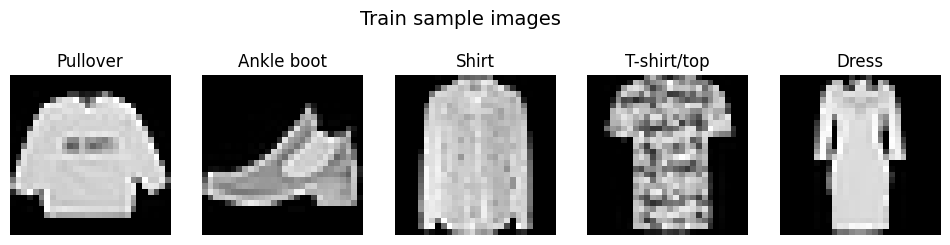

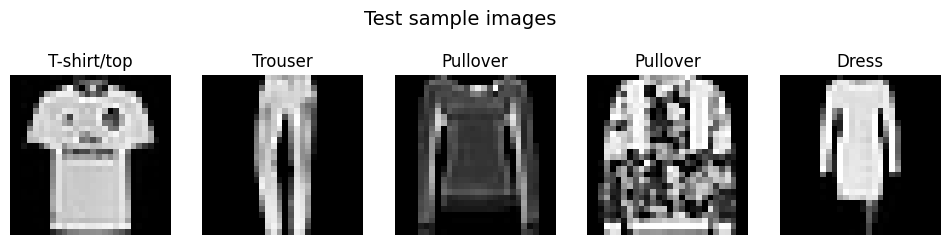

In [5]:
# Part 1: Data Loading for Fashion-MNIST from CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, zipfile
from pathlib import Path

zip_path = '/content/archive.zip'
extract_path = '/content/archive'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

train_set = pd.read_csv('/content/archive/fashion-mnist_train.csv')
test_set = pd.read_csv('/content/archive/fashion-mnist_test.csv')

print('Train set shape:', train_set.shape)
print('Test set shape :', test_set.shape)

# Display first 5 images from train and test
for split_name, df in [('Train', train_set), ('Test', test_set)]:
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'{split_name} sample images', fontsize=14)

    for i, ax in enumerate(axes):
        label = int(df.iloc[i]['label'])
        pixels = df.iloc[i].drop('label').values.reshape(28, 28)

        ax.imshow(pixels, cmap='gray', interpolation='nearest')
        ax.set_title(class_names[label])
        ax.axis('off')

    plt.show()

## Part 2: Feature Engineering

In this part, the Fashion-MNIST data was prepared as numerical feature vectors.

Each image in the dataset is a 28x28 grayscale image, represented in the CSV file as 784 pixel values. Therefore, each row already represents a flattened image vector.

The label column was separated from the pixel feature columns, so the pixel values could be used as input features and the label could be used as the target class.

Min-Max scaling was then applied to normalize the pixel values from the original range of 0-255 into the range of 0.0-1.0.

The scaler was fitted only on the training set and then applied to the test set, in order to avoid data leakage.

This preprocessing step is especially important for KNN because the algorithm relies on distance calculations between samples, and normalization helps ensure that all features are on the same scale.

Train pixels shape: (60000, 785)
Test pixels shape : (10000, 785)
Scaled train set shape: (60000, 785)
Scaled test set shape : (10000, 785)
Train set examples before scaling:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
0,2,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0


Train set examples after scaling:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019608,0.0,0.0


Test set examples before scaling:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
0,0,0,0,0,0,0,0,0,9,8,0
1,1,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,17


Test set examples after scaling:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.035294,0.031496,0.000000
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.000000,0.000000,0.000000
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0625,0.207843,0.389764,0.066667



Visualizing Feature Engineering (Min-Max Scaling):


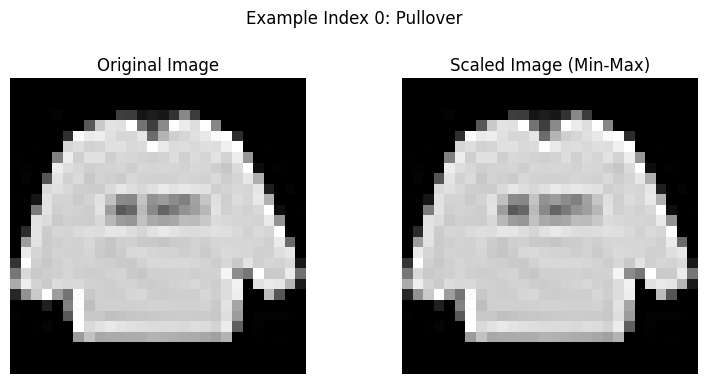

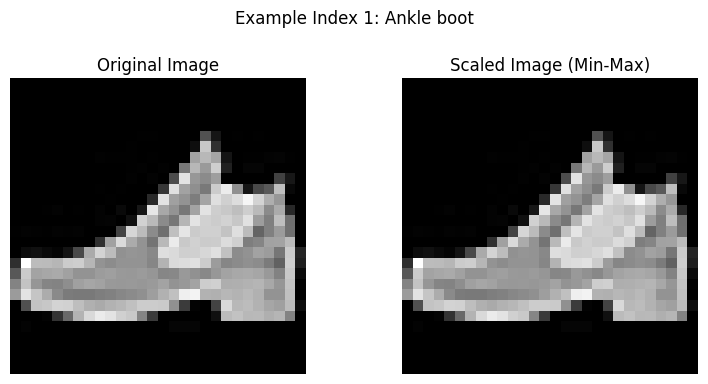

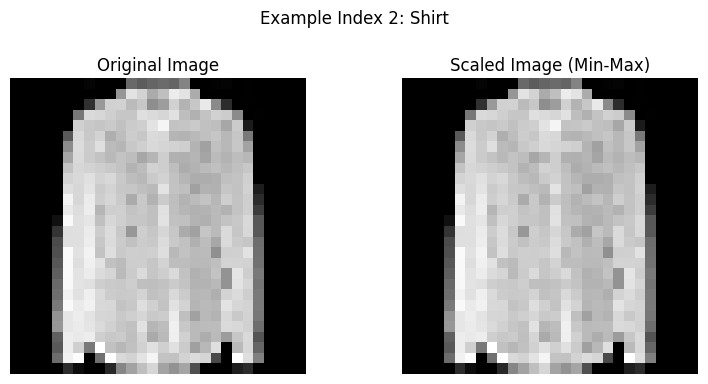

In [6]:
# Feature engineering: create flattened pixel vectors and apply Min-Max scaling
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# The train_set and test_set already contain pixel data, so the build_pixel_dataframe
# function is no longer needed. We can directly use the dataframes.
train_pixels = train_set.copy()
test_pixels = test_set.copy()

print('Train pixels shape:', train_pixels.shape)
print('Test pixels shape :', test_pixels.shape)

label_col = 'label'
feature_cols = [col for col in train_pixels.columns if col != label_col]

X_train = train_pixels[feature_cols].astype(float)
y_train = train_pixels[label_col].astype(int)
X_test = test_pixels[feature_cols].astype(float)
y_test = test_pixels[label_col].astype(int)

scaler = MinMaxScaler(feature_range=(0.0, 1.0))
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

train_set_scaled = pd.concat([y_train.reset_index(drop=True), X_train_scaled], axis=1)
test_set_scaled = pd.concat([y_test.reset_index(drop=True), X_test_scaled], axis=1)

print('Scaled train set shape:', train_set_scaled.shape)
print('Scaled test set shape :', test_set_scaled.shape)

example_indices = [0, 1, 2]
example_cols = feature_cols[:10]

print('Train set examples before scaling:')
display(train_pixels.loc[example_indices, [label_col] + list(example_cols)])

print('Train set examples after scaling:')
display(train_set_scaled.loc[example_indices, [label_col] + list(example_cols)])

print('Test set examples before scaling:')
display(test_pixels.loc[example_indices, [label_col] + list(example_cols)])

print('Test set examples after scaling:')
display(test_set_scaled.loc[example_indices, [label_col] + list(example_cols)])

# Code snippet to demonstrate feature engineering before and after Min-Max scaling
# Define class names for plotting
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Select 2-3 example indices
selected_indices = [0, 1, 2]

# Loop through each example index and display original vs. scaled images
print('\nVisualizing Feature Engineering (Min-Max Scaling):')
for idx in selected_indices:
    # Extract original pixel values and reshape to 28x28
    # We need to drop the label column first, then get values for the given index
    original_pixels = train_pixels.iloc[idx].drop(label_col).values.reshape(28, 28)
    # Extract scaled pixel values and reshape to 28x28
    scaled_pixels = train_set_scaled.iloc[idx].drop(label_col).values.reshape(28, 28)

    # Get the actual label for the title
    label = int(train_pixels.iloc[idx][label_col])

    # Display original and scaled images side by side
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f'Example Index {idx}: {class_names[label]}', fontsize=12)

    # Original Image
    axes[0].imshow(original_pixels, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off') # Remove axis ticks

    # Scaled Image
    axes[1].imshow(scaled_pixels, cmap='gray')
    axes[1].set_title('Scaled Image (Min-Max)')
    axes[1].axis('off') # Remove axis ticks

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

## Part 3: Implementing a K-Nearest Neighbors Classifier from Scratch

In this section we build the KNN algorithm without using any pre-built classifier from machine learning libraries. The implementation follows the core KNN ideas:

- **Training stage:** store the training feature matrix and labels.
- **Prediction stage:** for each query image, compute distances to all stored training images.
- **Sorting:** find the `k` nearest neighbors by distance.
- **Majority voting:** select the class label that appears most often among the nearest neighbors.

This implementation supports both `euclidean` and `manhattan` distance metrics and allows the user to choose `k`.

### KNN algorithm details

1. **Store training data** (`fit`): KNN is a lazy learner, so training only means remembering examples.
2. **Compute distances** (`_compute_distances`): use vectorized NumPy operations to calculate all distances from query examples to training examples.
3. **Select nearest neighbors**: sort each query's distances and take the smallest `k` indices.
4. **Vote on label** (`_vote`): count the labels of the nearest neighbors and choose the most frequent one.
5. **Handle ties**: if multiple classes have the same count, the smallest class label is chosen.

Selected train indices: [16292 16277 57618 32055   133 43734 37067 16659 25407 30804] ...
Selected test indices : [4138 9212 6473 3968 7260 6316 7966 8764 3190 1288 4575 4610 7194 7867
 1521  619 4962 3926 1530 4334]
Predicted labels      : [5 7 0 9 9 1 9 7 7 1 4 7 1 1 1 9 4 5 6 6]
Actual labels         : [5 7 0 7 9 1 9 7 7 1 4 7 1 1 1 9 6 5 2 2]


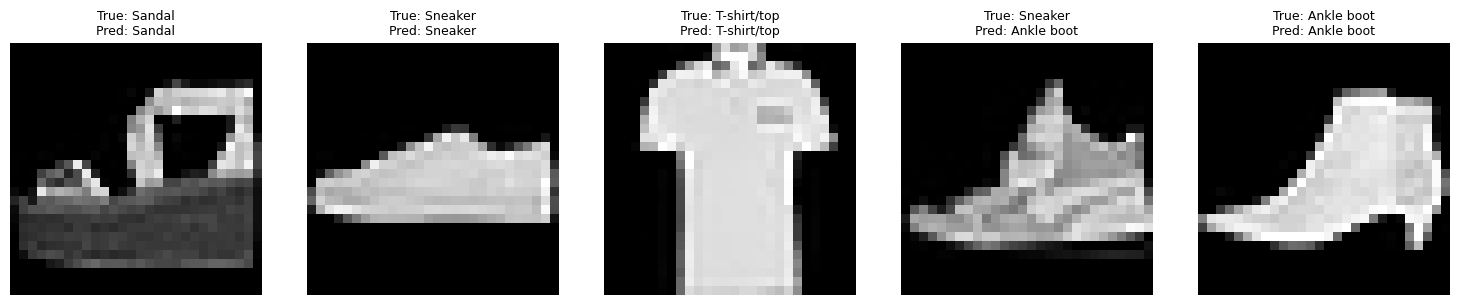

In [7]:
# Part 3: KNN from scratch implementation
import numpy as np

class KNNClassifier:
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = int(k)
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None
        self.n_classes_ = None

    def fit(self, X, y):
        """Store the training features and labels."""
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y, dtype=int)

        if self.X_train.ndim != 2:
            raise ValueError('X must be a 2D array of shape (n_samples, n_features)')
        if self.y_train.ndim != 1:
            raise ValueError('y must be a 1D array of labels')
        if self.X_train.shape[0] != self.y_train.shape[0]:
            raise ValueError('Number of samples in X and y must match')

        self.n_classes_ = int(self.y_train.max() + 1)
        return self

    def _compute_distances(self, X):
        """Compute distances between query points and all training points."""
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.X_train.shape[1]:
            raise ValueError('Number of features in X must match training data')

        if self.distance_metric == 'euclidean':
            # (n_queries, 1, n_features) - (1, n_train, n_features) => (n_queries, n_train, n_features)
            diff = X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]
            distances = np.sqrt(np.sum(diff ** 2, axis=2))
        elif self.distance_metric == 'manhattan':
            diff = X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]
            distances = np.sum(np.abs(diff), axis=2)
        else:
            raise ValueError("distance_metric must be 'euclidean' or 'manhattan'")

        return distances

    def _vote(self, neighbor_indices):
        """Return the majority label for each query from the neighbor indices."""
        votes = self.y_train[neighbor_indices]
        # Use bincount for fast counting and choose smallest label in case of ties.
        counts = np.bincount(votes, minlength=self.n_classes_)
        return np.argmax(counts)

    def predict(self, X):
        """Predict labels for the input query set X."""
        if self.X_train is None or self.y_train is None:
          raise ValueError('The model must be fitted before prediction')
        if self.k > len(self.y_train):
          raise ValueError('k cannot be larger than the number of training samples')
        distances = self._compute_distances(X)
        neighbor_indices = np.argsort(distances, axis=1)[:, : self.k]

        predictions = np.array([self._vote(indices) for indices in neighbor_indices], dtype=int)
        return predictions

# Example usage of the KNN classifier
X_train = train_set_scaled.drop(columns=['label']).values
y_train = train_set_scaled['label'].values
X_test = test_set_scaled.drop(columns=['label']).values

# Use a random sample from the training set so the subset includes multiple labels.
rng = np.random.default_rng(42)
train_indices = rng.choice(len(X_train), size=2000, replace=False)
X_train_small = X_train[train_indices]
y_train_small = y_train[train_indices]

# Select a random sample from the test set for prediction.
test_indices = rng.choice(len(X_test), size=20, replace=False)
X_test_small = X_test[test_indices]
y_test_small = test_set_scaled['label'].values[test_indices]

knn = KNNClassifier(k=5, distance_metric='euclidean')
knn.fit(X_train_small, y_train_small)

predictions = knn.predict(X_test_small)
print('Selected train indices:', train_indices[:10], '...')
print('Selected test indices :', test_indices)
print('Predicted labels      :', predictions)
print('Actual labels         :', y_test_small)
# ------------------------------------------------------------
# Display 5 example predictions from Part 3
# ------------------------------------------------------------

import matplotlib.pyplot as plt

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    image = X_test_small[i].reshape(28, 28)

    true_label = int(y_test_small[i])
    predicted_label = int(predictions[i])

    ax.imshow(image, cmap='gray')
    ax.set_title(
        f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}",
        fontsize=9
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## Part 6 - Bonus Preparation: Sampling the Dataset

Since manual KNN is computationally expensive and the full train set contains 60,000 samples, we used approximately one tenth of the train set. This keeps the experiment feasible while still following the assignment requirements for heavy datasets.

In [8]:
# ============================================================
# Part 6: Bonus Preparation - Sampling the Dataset
# Feature Engineering: PCA
# Hyperparameters: k, distance metric, PCA components
# Evaluation metric: Macro F1-score
# ============================================================

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
rng = np.random.default_rng(42)

# ------------------------------------------------------------
# Use scaled datasets from Part 2
# ------------------------------------------------------------
if 'train_set_scaled' not in globals() or 'test_set_scaled' not in globals():
    raise ValueError("Please run Part 2 first so train_set_scaled and test_set_scaled are available.")

# ------------------------------------------------------------
# Since full Fashion-MNIST train set has 60,000 samples,
# we use approximately one tenth of the data, as allowed for heavy datasets.
# ------------------------------------------------------------
TRAIN_SAMPLE_SIZE = 6000
TEST_SAMPLE_SIZE = 1000

train_indices = rng.choice(len(train_set_scaled), size=TRAIN_SAMPLE_SIZE, replace=False)
test_indices = rng.choice(len(test_set_scaled), size=TEST_SAMPLE_SIZE, replace=False)

X_train_sample = train_set_scaled.drop(columns=['label']).values[train_indices]
y_train_sample = train_set_scaled['label'].values[train_indices]

X_test_sample = test_set_scaled.drop(columns=['label']).values[test_indices]
y_test_sample = test_set_scaled['label'].values[test_indices]

# ------------------------------------------------------------
# Additional Feature Engineering:
# StandardScaler
# ------------------------------------------------------------

standard_scaler = StandardScaler()
X_train_sample_standard = standard_scaler.fit_transform(X_train_sample)
X_test_sample_standard = standard_scaler.transform(X_test_sample)

print(f"Training sample size: {X_train_sample.shape}")
print(f"Test sample size: {X_test_sample.shape}")

Training sample size: (6000, 784)
Test sample size: (1000, 784)


### 6A - Manual 5-Fold Cross Validation

In this section, we implement a manual 5-Fold Cross Validation process.The training sample is divided into 5 folds. In each iteration, 4 folds are used for training and 1 fold is used for validation.

For each fold:
- PCA is fitted only on the training folds
- The validation fold is transformed using the same PCA model
- The KNN model is trained and evaluated
- The Macro F1-score is calculated

The final performance for each configuration is computed as the average Macro F1-score across all 5 folds, along with the standard deviation.

In [9]:
def manual_5_fold_cv(X, y, k, distance_metric, pca_components, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = np.arange(len(X))
    rng.shuffle(indices)


    X_shuffled = X[indices]
    y_shuffled = y[indices]

    num_folds = 5
    fold_size = len(X) // num_folds

    fold_scores = []

    for fold in range(num_folds):
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size if fold < num_folds - 1 else len(X)

        X_val = X_shuffled[val_start:val_end]
        y_val = y_shuffled[val_start:val_end]

        X_train_fold = np.concatenate([
            X_shuffled[:val_start],
            X_shuffled[val_end:]
        ])

        y_train_fold = np.concatenate([
            y_shuffled[:val_start],
            y_shuffled[val_end:]
        ])

        # Feature Engineering: PCA
        pca = PCA(n_components=pca_components, random_state=42)
        X_train_fold_pca = pca.fit_transform(X_train_fold)
        X_val_pca = pca.transform(X_val)

        # Train manual KNN
        model = KNNClassifier(k=k, distance_metric=distance_metric)
        model.fit(X_train_fold_pca, y_train_fold)

        # Predict validation fold
        y_pred = model.predict(X_val_pca)

        # Macro F1-score
        score = f1_score(y_val, y_pred, average='macro')
        fold_scores.append(score)

    return np.mean(fold_scores), np.std(fold_scores), fold_scores

### 6B + 6C - Feature Engineering and Hyperparameter Experiments

In this experiment, multiple feature engineering methods and hyperparameters are evaluated.

The feature engineering methods tested are:
- Min-Max Scaling
- Standard Scaling

In addition, PCA is applied as a dimensionality reduction step, with different numbers of components:
- 30 components
- 50 components

The KNN hyperparameters tested are:
- Number of neighbors: k = 3, 5, 7
- Distance metric:
  - Euclidean distance
  - Manhattan distance

### Grid Search Over All Selected Permutations

The code performs a Grid Search over all combinations of:
- Feature engineering method
- Number of PCA components
- Number of neighbors k
- Distance metric

Each combination is evaluated using manual 5-Fold Cross Validation.

### 6G - Presenting the Experiments

All experiment results are stored in a DataFrame.

For each permutation, the table presents:
- Feature engineering method
- k value
- Distance metric
- Number of PCA components
- F1-score for each fold
- Mean Macro F1-score across the 5 folds
- Standard deviation of the Macro F1 scores

In [10]:
# ------------------------------------------------------------
# Grid Search Hyperparameters
# ------------------------------------------------------------

k_values = [3, 5, 7]
distance_metrics = ['euclidean', 'manhattan']
pca_components_values = [30, 50]

feature_engineering_methods = ['minmax', 'standard']

results = []

for fe_method in feature_engineering_methods:

    if fe_method == 'minmax':
        current_X_train = X_train_sample
    elif fe_method == 'standard':
        current_X_train = X_train_sample_standard
    else:
        raise ValueError("Unsupported feature engineering method")

    for k in k_values:
        for distance_metric in distance_metrics:
            for pca_components in pca_components_values:

                mean_f1, std_f1, fold_scores = manual_5_fold_cv(
                    current_X_train,
                    y_train_sample,
                    k=k,
                    distance_metric=distance_metric,
                    pca_components=pca_components
                )

                results.append({
                    'feature_engineering': fe_method,
                    'k': k,
                    'distance_metric': distance_metric,
                    'pca_components': pca_components,
                    'fold_1_f1': fold_scores[0],
                    'fold_2_f1': fold_scores[1],
                    'fold_3_f1': fold_scores[2],
                    'fold_4_f1': fold_scores[3],
                    'fold_5_f1': fold_scores[4],
                    'mean_macro_f1': mean_f1,
                    'std_macro_f1': std_f1
                })

                print(
                    f"FE={fe_method}, k={k}, distance={distance_metric}, PCA={pca_components} "
                    f"=> Mean Macro F1={mean_f1:.4f}, STD={std_f1:.4f}"
                )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='mean_macro_f1',
    ascending=False
).reset_index(drop=True)

print("Grid Search Results:")
display(results_df)

FE=minmax, k=3, distance=euclidean, PCA=30 => Mean Macro F1=0.8024, STD=0.0106
FE=minmax, k=3, distance=euclidean, PCA=50 => Mean Macro F1=0.8095, STD=0.0070
FE=minmax, k=3, distance=manhattan, PCA=30 => Mean Macro F1=0.8034, STD=0.0067
FE=minmax, k=3, distance=manhattan, PCA=50 => Mean Macro F1=0.8135, STD=0.0080
FE=minmax, k=5, distance=euclidean, PCA=30 => Mean Macro F1=0.8034, STD=0.0077
FE=minmax, k=5, distance=euclidean, PCA=50 => Mean Macro F1=0.8129, STD=0.0055
FE=minmax, k=5, distance=manhattan, PCA=30 => Mean Macro F1=0.8045, STD=0.0075
FE=minmax, k=5, distance=manhattan, PCA=50 => Mean Macro F1=0.8138, STD=0.0078
FE=minmax, k=7, distance=euclidean, PCA=30 => Mean Macro F1=0.8067, STD=0.0058
FE=minmax, k=7, distance=euclidean, PCA=50 => Mean Macro F1=0.8133, STD=0.0029
FE=minmax, k=7, distance=manhattan, PCA=30 => Mean Macro F1=0.8073, STD=0.0093
FE=minmax, k=7, distance=manhattan, PCA=50 => Mean Macro F1=0.8165, STD=0.0059
FE=standard, k=3, distance=euclidean, PCA=30 => Mean

,feature_engineering,k,distance_metric,pca_components,fold_1_f1,fold_2_f1,fold_3_f1,fold_4_f1,fold_5_f1,mean_macro_f1,std_macro_f1
0,standard,5,manhattan,50,0.801928,0.821165,0.812678,0.826547,0.826083,0.817680,0.009322
1,minmax,7,manhattan,50,0.809485,0.810353,0.816984,0.824109,0.821807,0.816548,0.005887
2,standard,3,manhattan,50,0.802716,0.813342,0.816122,0.827131,0.815043,0.814871,0.007772
3,standard,7,manhattan,50,0.798329,0.814492,0.810879,0.826412,0.823107,0.814644,0.009904
4,minmax,5,manhattan,50,0.805651,0.804194,0.821497,0.822831,0.815058,0.813846,0.007760
5,minmax,3,manhattan,50,0.801072,0.808814,0.824405,0.818682,0.814565,0.813507,0.008041
6,minmax,7,euclidean,50,0.808665,0.813564,0.811865,0.815911,0.816523,0.813305,0.002857
7,minmax,5,euclidean,50,0.806975,0.809784,0.810206,0.814694,0.822654,0.812863,0.005485
8,standard,7,euclidean,50,0.800861,0.814315,0.799607,0.823666,0.814816,0.810653,0.009143
9,standard,5,euclidean,50,0.803022,0.811740,0.792389,0.825579,0.819428,0.810432,0.011769


### Best Configuration Selection

The best configuration is selected according to the highest average Macro F1-score across the 5 validation folds.

In [15]:
# ------------------------------------------------------------
# Best configuration
# ------------------------------------------------------------

best_config = results_df.iloc[0]

best_feature_engineering = best_config['feature_engineering']
best_k = int(best_config['k'])
best_distance = best_config['distance_metric']
best_pca_components = int(best_config['pca_components'])

print("Best Configuration:")
print(f"Feature Engineering = {best_feature_engineering}")
print(f"k = {best_k}")
print(f"distance metric = {best_distance}")
print(f"PCA components = {best_pca_components}")
print(f"Best mean Macro F1 = {best_config['mean_macro_f1']:.4f}")
display(best_config)

Best Configuration:
Feature Engineering = standard
k = 5
distance metric = manhattan
PCA components = 50
Best mean Macro F1 = 0.8177


,0
feature_engineering,standard
k,5
distance_metric,manhattan
pca_components,50
fold_1_f1,0.801928
fold_2_f1,0.821165
fold_3_f1,0.812678
fold_4_f1,0.826547
fold_5_f1,0.826083
mean_macro_f1,0.81768


## Part 4 - Training Flow

After completing the bonus Grid Search and 5-Fold Cross Validation process, the best configuration was selected.

According to the assignment instructions, when using extensions from Part 6, the final model should be trained again using the best configuration.

Therefore, in this section, the final KNN model is trained using:
- The best value of k
- The selected distance metric
- The best PCA configuration

In addition, several training examples are presented before and after the PCA transformation in order to demonstrate the feature engineering process used in the final model.

In [16]:
# ------------------------------------------------------------
# Select best feature engineering dataset
# ------------------------------------------------------------

if best_feature_engineering == 'minmax':
    X_train_best = X_train_sample
    X_test_best = X_test_sample

elif best_feature_engineering == 'standard':
    X_train_best = X_train_sample_standard
    X_test_best = X_test_sample_standard

else:
    raise ValueError("Unsupported feature engineering method")

In [17]:
final_pca = PCA(n_components=best_pca_components, random_state=42)

X_train_final = final_pca.fit_transform(X_train_best)
X_test_final = final_pca.transform(X_test_best)

final_model = KNNClassifier(k=best_k, distance_metric=best_distance)
final_model.fit(X_train_final, y_train_sample)

print("Final model was trained using the best configuration.")
print(f"k = {best_k}")
print(f"distance metric = {best_distance}")
print(f"PCA components = {best_pca_components}")

# ------------------------------------------------------------
# Show 3 examples before and after PCA feature engineering
# ------------------------------------------------------------

example_indices = [0, 1, 2]

print("Original feature vectors before PCA:")
display(pd.DataFrame(
    X_train_best[example_indices, :10],
    columns=[f'pixel{i}' for i in range(10)]
))

print("Feature vectors after PCA:")
display(pd.DataFrame(
    X_train_final[example_indices, :10],
    columns=[f'PC{i+1}' for i in range(10)]
))

Final model was trained using the best configuration.
k = 5
distance metric = manhattan
PCA components = 50
Original feature vectors before PCA:


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9
0,-0.012911,-0.044081,-0.043915,-0.039315,-0.0612,-0.071031,-0.095266,-0.14423,-0.228189,-0.381128
1,-0.012911,-0.044081,-0.043915,-0.039315,-0.0612,-0.071031,-0.095266,-0.14423,-0.228189,-0.381128
2,-0.012911,-0.044081,-0.043915,-0.039315,-0.0612,-0.071031,-0.095266,-0.14423,-0.228189,0.516255


Feature vectors after PCA:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-14.499359,3.622547,3.704747,-11.916545,4.081612,0.456193,0.463678,10.537514,-3.833772,-4.189800
1,0.003268,16.063041,0.651703,-3.957352,-2.079140,5.845184,6.601473,-0.160788,4.486148,0.569604
2,11.310911,-12.294513,-6.023533,-4.194830,-0.415547,-0.113445,-0.121681,0.380111,-0.612450,-1.954354


## Part 5 - Prediction and Evaluation on the Test Set

In this section, the final trained model is evaluated on the test set.

The model predicts the labels of unseen test images, and the quality of the model is measured using the Macro F1-score, which is the required metric for multi-class classification problems.

In addition, the first 5 predictions are displayed together with their true labels.
The same PCA transformation that was fitted on the training data is also applied to the test data before prediction, so the test samples go through the same feature engineering process as the training samples.

Final Macro F1 on test sample: 0.8122
Original test feature vectors before PCA:


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9
0,-0.012911,-0.044081,-0.043915,-0.039315,-0.0612,0.086407,-0.095266,-0.14423,0.952062,3.815455
1,-0.012911,-0.044081,-0.043915,-0.039315,-0.0612,-0.071031,-0.095266,-0.14423,-0.228189,-0.381128
2,-0.012911,-0.044081,-0.043915,-0.039315,-0.0612,-0.071031,-0.095266,-0.14423,-0.228189,-0.381128


Test feature vectors after PCA:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,29.059188,17.666934,6.435297,6.500186,4.167747,-3.109504,2.376896,10.062748,10.739770,0.769319
1,-11.553985,5.311929,3.188648,-1.635818,4.875994,-2.467669,1.894584,-3.117919,-0.713511,-1.346845
2,16.168389,-10.255413,-8.527786,-3.235085,0.646171,8.802428,-2.471834,-1.171823,-1.854359,-1.661161


,True Label,Predicted Label
0,Pullover,Pullover
1,Bag,Sandal
2,Shirt,T-shirt/top
3,Pullover,Pullover
4,Ankle boot,Ankle boot


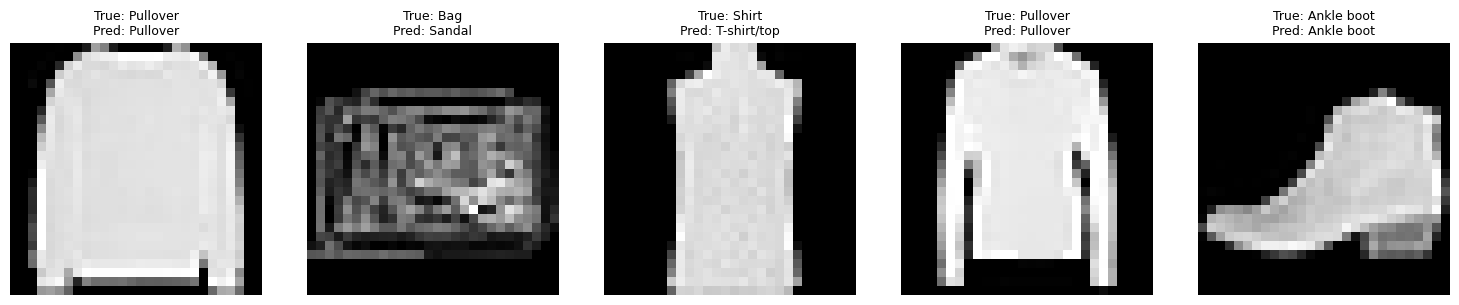

In [18]:
import matplotlib.pyplot as plt

y_test_pred = final_model.predict(X_test_final)
test_macro_f1 = f1_score(y_test_sample, y_test_pred, average='macro')
print(f"Final Macro F1 on test sample: {test_macro_f1:.4f}")

# ------------------------------------------------------------
# Show test samples before and after PCA transformation
# ------------------------------------------------------------

example_indices = [0, 1, 2]

print("Original test feature vectors before PCA:")
display(pd.DataFrame(
    X_test_best[example_indices, :10],
    columns=[f'pixel{i}' for i in range(10)]
))

print("Test feature vectors after PCA:")
display(pd.DataFrame(
    X_test_final[example_indices, :10],
    columns=[f'PC{i+1}' for i in range(10)]
))

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

predictions_df = pd.DataFrame({
    'True Label': [class_names[label] for label in y_test_sample[:5]],
    'Predicted Label': [class_names[label] for label in y_test_pred[:5]]
})

display(predictions_df)

# Display images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):

    image = X_test_sample[i].reshape(28, 28)

    true_label = class_names[y_test_sample[i]]
    predicted_label = class_names[y_test_pred[i]]

    ax.imshow(image, cmap='gray')

    ax.set_title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontsize=9
    )

    ax.axis('off')

plt.tight_layout()
plt.show()